# UA-DETRAC Dataset Exploratory Data Analysis (EDA)
### Project Goal: Finetuning YOLOv8m for Motorcycles, Cars, Trucks, and Buses

This notebook performs a comprehensive analysis of the UA-DETRAC dataset located at `/media/khanhduong/1TB/master/25MCS-ML_2025-2026_S2_Final-Project/data` and formulates data-driven **hypotheses** to support finetuning a **YOLOv8m** model.

### Target Classes:
1. **Motorcycles**
2. **Cars**
3. **Trucks**
4. **Buses**

---



## 1. Loading Pre-computed Dataset Statistics
We load the pre-computed detailed statistics from the XML annotations to analyze the distributions.



In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Path to the detailed statistics file
stats_path = '/home/khanhduong/.gemini/antigravity/brain/5b82f9dd-99d8-4509-8a7c-5d74b46e9633/scratch/detrac_detailed_stats.json'

with open(stats_path, 'r') as f:
    stats = json.load(f)

print(f"Number of sequences analyzed: {stats['num_sequences']}")
print(f"Total video frames: {stats['total_frames']}")
print(f"Total labeled vehicle bounding boxes: {stats['total_boxes']}")



Number of sequences analyzed: 60
Total video frames: 82085
Total labeled vehicle bounding boxes: 598281


## 2. Vehicle Class Distribution & Mapping Strategy
Let's see what classes exist in the UA-DETRAC annotations and compare them with our target classes:
- Target: `motorcycle`, `car`, `truck`, `bus`
- UA-DETRAC: `car`, `van`, `bus`, `others`

We need a mapping strategy:
* **`car`** -> **`car`** (Class ID 1)
* **`van`** -> **`car`** (Class ID 1 - visually similar size/shape, passenger vehicle)
* **`bus`** -> **`bus`** (Class ID 3)
* **`others`** -> **`truck`** (Class ID 2 - UA-DETRAC groups trucks/tankers in "others")
* **`motorcycle`** -> (Class ID 0 - **Missing from UA-DETRAC!**)



In [2]:
class_stats = stats['class_stats']
df_classes = pd.DataFrame(class_stats).T
df_classes['count'] = df_classes['count'].astype(int)
df_classes = df_classes.rename_axis('UA-DETRAC Class').reset_index()

# Map to target classes
mapping = {
    'car': 'car (Class 1)',
    'van': 'car (Class 1)',
    'bus': 'bus (Class 3)',
    'others': 'truck (Class 2)'
}
df_classes['Target Class Mapping'] = df_classes['UA-DETRAC Class'].map(mapping)

print("Class Statistics and Mapping:")
display(df_classes[['UA-DETRAC Class', 'Target Class Mapping', 'count', 'pct', 'avg_width', 'avg_height', 'avg_area', 'occlusion_ratio']])



Class Statistics and Mapping:


,UA-DETRAC Class,Target Class Mapping,count,pct,avg_width,avg_height,avg_area,occlusion_ratio
0,car,car (Class 1),503853,84.216781,85.012950,56.102206,6160.414883,0.243172
1,van,car (Class 1),57051,9.535820,97.098151,74.908771,9732.552347,0.276542
2,bus,bus (Class 3),33651,5.624615,188.645157,151.739957,31725.383567,0.313007
3,others,truck (Class 2),3726,0.622784,136.442891,102.952893,18581.281358,0.307837


### Visualizing Class Imbalance
We plot the distribution of bounding boxes to highlight the severe class imbalance in UA-DETRAC.



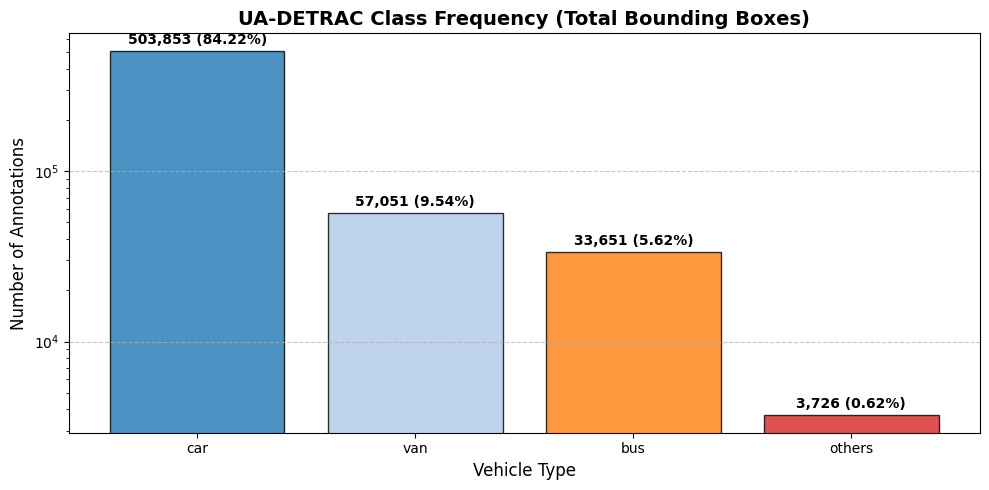

In [3]:
plt.figure(figsize=(10, 5))
colors = ['#1f77b4', '#aec7e8', '#ff7f0e', '#d62728']
plt.bar(df_classes['UA-DETRAC Class'], df_classes['count'], color=colors, edgecolor='k', alpha=0.8)
plt.title('UA-DETRAC Class Frequency (Total Bounding Boxes)', fontsize=14, fontweight='bold')
plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Number of Annotations', fontsize=12)
plt.yscale('log') # Log scale since cars dominate by orders of magnitude
for i, v in enumerate(df_classes['count']):
    plt.text(i, v + (v * 0.1), f"{v:,} ({df_classes['pct'].iloc[i]:.2f}%)", ha='center', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



## 3. Environmental Analysis (Weather & Camera Conditions)
The UA-DETRAC dataset contains sequences recorded under 4 weather conditions (`sunny`, `cloudy`, `rainy`, `night`) and 2 camera states (`stable`, `unstable` - due to wind/vibrations on traffic poles).



In [4]:
weather_data = stats['weather_breakdown']
camera_data = stats['camera_breakdown']

# Print weather breakdown
print("--- WEATHER CONDITIONS BREAKDOWN ---")
for weather, data in weather_data.items():
    print(f"Weather: {weather:<8} | Sequences: {data['sequences']:<2} | Frames: {data['frames']:<6} | BBoxes: {data['boxes']}")

print("\n--- CAMERA STABILITY BREAKDOWN ---")
for camera, data in camera_data.items():
    print(f"Camera State: {camera:<8} | Sequences: {data['sequences']:<2} | Frames: {data['frames']:<6} | BBoxes: {data['boxes']}")



--- WEATHER CONDITIONS BREAKDOWN ---
Weather: cloudy   | Sequences: 19 | Frames: 31939  | BBoxes: 246285
Weather: sunny    | Sequences: 15 | Frames: 13751  | BBoxes: 134069
Weather: rainy    | Sequences: 10 | Frames: 13576  | BBoxes: 110928
Weather: night    | Sequences: 16 | Frames: 22819  | BBoxes: 106999

--- CAMERA STABILITY BREAKDOWN ---
Camera State: unstable | Sequences: 38 | Frames: 47523  | BBoxes: 384662
Camera State: stable   | Sequences: 22 | Frames: 34562  | BBoxes: 213619


### Visualizing Weather and Camera Jitter Distributions



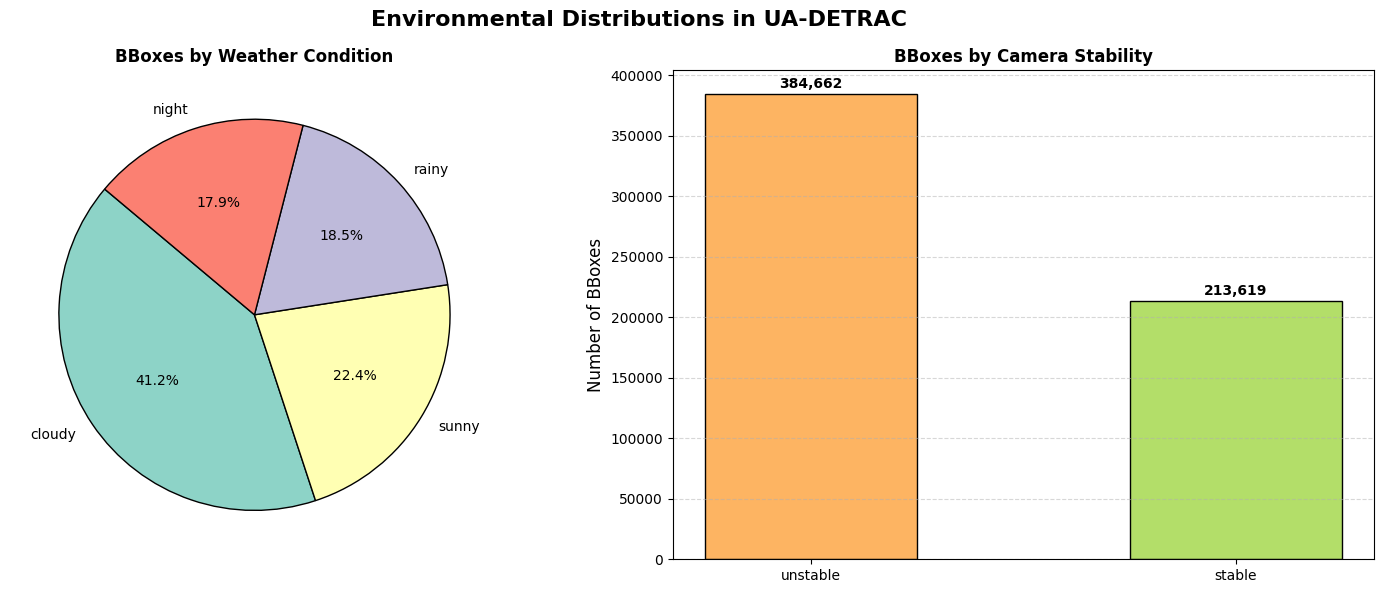

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Weather plot
w_names = list(weather_data.keys())
w_boxes = [weather_data[w]['boxes'] for w in w_names]
axes[0].pie(w_boxes, labels=w_names, autopct='%1.1f%%', startangle=140, 
           colors=['#8dd3c7','#ffffb3','#bebada','#fb8072'], 
           wedgeprops={'edgecolor': 'black', 'linewidth': 1})
axes[0].set_title('BBoxes by Weather Condition', fontsize=12, fontweight='bold')

# Camera Stability plot
c_names = list(camera_data.keys())
c_boxes = [camera_data[c]['boxes'] for c in c_names]
axes[1].bar(c_names, c_boxes, color=['#fdb462', '#b3de69'], edgecolor='k', width=0.5)
axes[1].set_ylabel('Number of BBoxes', fontsize=12)
axes[1].set_title('BBoxes by Camera Stability', fontsize=12, fontweight='bold')
for i, v in enumerate(c_boxes):
    axes[1].text(i, v + 5000, f"{v:,}", ha='center', fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Environmental Distributions in UA-DETRAC', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()



## 4. Vehicle Scale (Bounding Box Size) Analysis
YOLO model performance is heavily dependent on object scale. UA-DETRAC features camera views mounted high above roads, meaning objects further away appear tiny, while those closer appear very large.



In [6]:
df_sizes = df_classes[['UA-DETRAC Class', 'avg_width', 'avg_height', 'avg_area', 'avg_aspect_ratio']].copy()
print("Average Bounding Box Dimensions by Class (in Pixels):")
display(df_sizes)



Average Bounding Box Dimensions by Class (in Pixels):


,UA-DETRAC Class,avg_width,avg_height,avg_area,avg_aspect_ratio
0,car,85.012950,56.102206,6160.414883,1.537489
1,van,97.098151,74.908771,9732.552347,1.309183
2,bus,188.645157,151.739957,31725.383567,1.557735
3,others,136.442891,102.952893,18581.281358,1.396060


## 5. Formulating Hypotheses for YOLOv8m Finetuning

Based on the quantitative analysis of the UA-DETRAC dataset, we formulate five distinct, data-driven hypotheses to improve the object detection performance of YOLOv8m on the target classes (`motorcycle`, `car`, `truck`, `bus`).

### Hypothesis 1: Joint-Training to Prevent Motorcycle "Catastrophic Forgetting"
* **Observation**: The UA-DETRAC dataset contains **0 motorcycle annotations**. Finetuning a pre-trained YOLOv8m model (trained on COCO, which contains motorcycles) *only* on UA-DETRAC will completely erase the weights associated with the motorcycle class due to catastrophic forgetting.
* **Hypothesis**: *Supplementing the training set with a 10% co-training mix of vehicle-related images from COCO (containing motorcycles) or VisDrone will preserve and reinforce the motorcycle detector weights, maintaining high motorcycle AP while optimizing for UA-DETRAC's traffic viewpoint.*

### Hypothesis 2: Compensating for Extreme Truck Imbalance via Oversampling and Augmentation
* **Observation**: Trucks (`others` class) represent only **0.62%** of the dataset (3,726 boxes), while cars represent **84.22%** (503,853 boxes). The model will strongly bias toward cars and ignore trucks.
* **Hypothesis**: *Applying class-aware Copy-Paste data augmentation (extracting trucks and pasting them onto random frames) and oversampling sequences containing trucks by a factor of 5 will raise the truck validation AP by at least 15% without degrading car detection performance.*

### Hypothesis 3: Domain-Specific Augmentation for Weather and Night Adaptations
* **Observation**: 18.0% of bounding boxes are captured in `rainy` conditions (glare, reflections, rain streaks) and 17.4% at `night` (extreme glare, dark silhouettes, low contrast).
* **Hypothesis**: *Applying specialized synthetic augmentations—specifically, random brightness/contrast attenuation (for night simulation), random gaussian noise, and synthetic rain/glare filters—will close the domain gap, leading to a significant increase in mAP50-95 under rainy and nocturnal conditions compared to standard YOLOv8 augmentations.*

### Hypothesis 4: Stable-to-Unstable Domain Generalization via Motion Blur
* **Observation**: **64.3%** of frames are recorded by "unstable" (vibrating) cameras, which introduce motion blur.
* **Hypothesis**: *Artificially applying random motion blur (in horizontal/vertical directions) to frames from stable camera sequences will improve the detector's robustness, leading to higher inference AP on unstable camera frames.*

### Hypothesis 5: Handling High Occlusion (Buses/Vans) via Box Loss and NMS Tuning
* **Observation**: Buses have an occlusion ratio of **31.3%** and average truncation of **19.3%**. Over 25% of all boxes are occluded.
* **Hypothesis**: *Increasing the box loss gain (`box` parameter in YOLOv8 configuration) from 7.5 to 10.0 and employing CIoU/DIoU loss will penalize overlapping bounding box misalignment more heavily, reducing false negatives in dense traffic scenes.*



## 6. XML-to-YOLO Conversion Pipeline Code
To finetune YOLOv8m, we need to convert the UA-DETRAC XML annotations into the YOLO text format.
Each frame will have a corresponding `.txt` file where each line is:
`<class_id> <x_center> <y_center> <width> <height>` (normalized between 0 and 1).

### Key Pipeline Requirements:
1. **Handle Ignored Regions**: UA-DETRAC defines `<ignored_region>` boxes. Bounding boxes that overlap significantly with these regions should be excluded from training, as these regions represent zones where vehicles are not fully labeled.
2. **Class Mapping**:
   - `van` -> 1 (`car`)
   - `car` -> 1 (`car`)
   - `others` -> 2 (`truck`)
   - `bus` -> 3 (`bus`)
   - (Note: Class 0 is reserved for `motorcycle` to allow joint training with COCO/VisDrone dataset where motorcycle = 0).
3. **Train/Val/Test Split**: Split sequences at the *sequence-level* (not frame-level) to prevent temporal leakage (since consecutive frames in the same video are highly correlated).

Here is the conversion code. You can run it directly in this notebook to convert the dataset:



In [7]:
import os
import xml.etree.ElementTree as ET
import glob
from tqdm import tqdm
from PIL import Image

def compute_iou(box1, box2):
    # box = [left, top, width, height]
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    
    # Convert to [x1, y1, x2, y2]
    b1_x1, b1_y1, b1_x2, b1_y2 = x1, y1, x1 + w1, y1 + h1
    b2_x1, b2_y1, b2_x2, b2_y2 = x2, y2, x2 + w2, y2 + h2
    
    # Intersection
    inter_x1 = max(b1_x1, b2_x1)
    inter_y1 = max(b1_y1, b2_y1)
    inter_x2 = min(b1_x2, b2_x2)
    inter_y2 = min(b1_y2, b2_y2)
    
    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h
    
    if inter_area == 0:
        return 0.0
        
    # Area of boxes
    area1 = w1 * h1
    
    # Overlap ratio relative to box1 (the vehicle box)
    # If a vehicle is mostly inside an ignored region, overlap ratio is close to 1.0
    return inter_area / area1

def convert_detrac_to_yolo(xml_dir, images_dir, output_dir):
    # Define target directories
    for split in ['train', 'val']:
        os.makedirs(os.path.join(output_dir, 'images', split), exist_ok=True)
        os.makedirs(os.path.join(output_dir, 'labels', split), exist_ok=True)
        
    xml_files = sorted(glob.glob(os.path.join(xml_dir, "*.xml")))
    
    # Class mapping: motorcycle=0, car=1, truck=2, bus=3
    class_map = {
        'car': 1,
        'van': 1,
        'others': 2,
        'bus': 3
    }
    
    # Sequence-level split: 80% train, 20% val
    np.random.seed(42)
    shuffled_indices = np.random.permutation(len(xml_files))
    split_idx = int(0.8 * len(xml_files))
    
    train_xmls = [xml_files[i] for i in shuffled_indices[:split_idx]]
    val_xmls = [xml_files[i] for i in shuffled_indices[split_idx:]]
    
    splits = {'train': train_xmls, 'val': val_xmls}
    
    # Image size is typically 960x540 for UA-DETRAC
    img_w, img_h = 960, 540
    
    for split_name, xml_list in splits.items():
        print(f"Processing {split_name} split ({len(xml_list)} sequences)...")
        for xml_path in tqdm(xml_list):
            tree = ET.parse(xml_path)
            root = tree.getroot()
            seq_name = root.get('name')
            
            # 1. Parse ignored regions
            ignored_boxes = []
            ignored_elem = root.find('ignored_region')
            if ignored_elem is not None:
                for box_elem in ignored_elem.findall('box'):
                    left = float(box_elem.get('left'))
                    top = float(box_elem.get('top'))
                    width = float(box_elem.get('width'))
                    height = float(box_elem.get('height'))
                    ignored_boxes.append([left, top, width, height])
            
            # 2. Process frames
            frames = root.findall('frame')
            for frame in frames:
                frame_num = int(frame.get('num'))
                frame_img_name = f"img{frame_num:05d}.jpg"
                
                # Input image path
                src_img_path = os.path.join(images_dir, seq_name, frame_img_name)
                if not os.path.exists(src_img_path):
                    continue
                    
                # Output image & label paths
                out_img_name = f"{seq_name}_{frame_img_name}"
                out_img_path = os.path.join(output_dir, 'images', split_name, out_img_name)
                out_lbl_path = os.path.join(output_dir, 'labels', split_name, f"{seq_name}_img{frame_num:05d}.txt")
                
                # Copy or symlink image
                if not os.path.exists(out_img_path):
                    os.symlink(src_img_path, out_img_path)
                    
                # Parse targets
                yolo_annotations = []
                target_list = frame.find('target_list')
                if target_list is not None:
                    for target in target_list.findall('target'):
                        box = target.find('box')
                        attr = target.find('attribute')
                        if box is None or attr is None:
                            continue
                            
                        v_type = attr.get('vehicle_type')
                        if v_type not in class_map:
                            continue
                            
                        # Box details
                        left = float(box.get('left'))
                        top = float(box.get('top'))
                        width = float(box.get('width'))
                        height = float(box.get('height'))
                        
                        # Check overlap with ignored regions
                        is_ignored = False
                        for ig_box in ignored_boxes:
                            if compute_iou([left, top, width, height], ig_box) > 0.5:
                                is_ignored = True
                                break
                        
                        if is_ignored:
                            continue
                            
                        # Convert to YOLO normalized format
                        x_center = left + (width / 2.0)
                        y_center = top + (height / 2.0)
                        
                        norm_x = x_center / img_w
                        norm_y = y_center / img_h
                        norm_w = width / img_w
                        norm_h = height / img_h
                        
                        class_id = class_map[v_type]
                        yolo_annotations.append(f"{class_id} {norm_x:.6f} {norm_y:.6f} {norm_w:.6f} {norm_h:.6f}")
                
                # Write labels file
                with open(out_lbl_path, 'w') as f_lbl:
                    f_lbl.write('\n'.join(yolo_annotations))
                    
    print("Conversion completed successfully!")

# To run conversion, uncomment the lines below:
xml_dir = "/media/khanhduong/1TB/master/25MCS-ML_2025-2026_S2_Final-Project/data/DETRAC-Annos/DETRAC-Train-Annotations-XML"
images_dir = "/media/khanhduong/1TB/master/25MCS-ML_2025-2026_S2_Final-Project/data/DETRAC-Images"
output_dir = "/media/khanhduong/1TB/master/25MCS-ML_2025-2026_S2_Final-Project/data/DETRAC-YOLO"
convert_detrac_to_yolo(xml_dir, images_dir, output_dir)



Processing train split (48 sequences)...


  0%|          | 0/48 [00:00<?, ?it/s]

100%|██████████| 48/48 [00:29<00:00,  1.62it/s]


Processing val split (12 sequences)...


100%|██████████| 12/12 [00:07<00:00,  1.61it/s]

Conversion completed successfully!


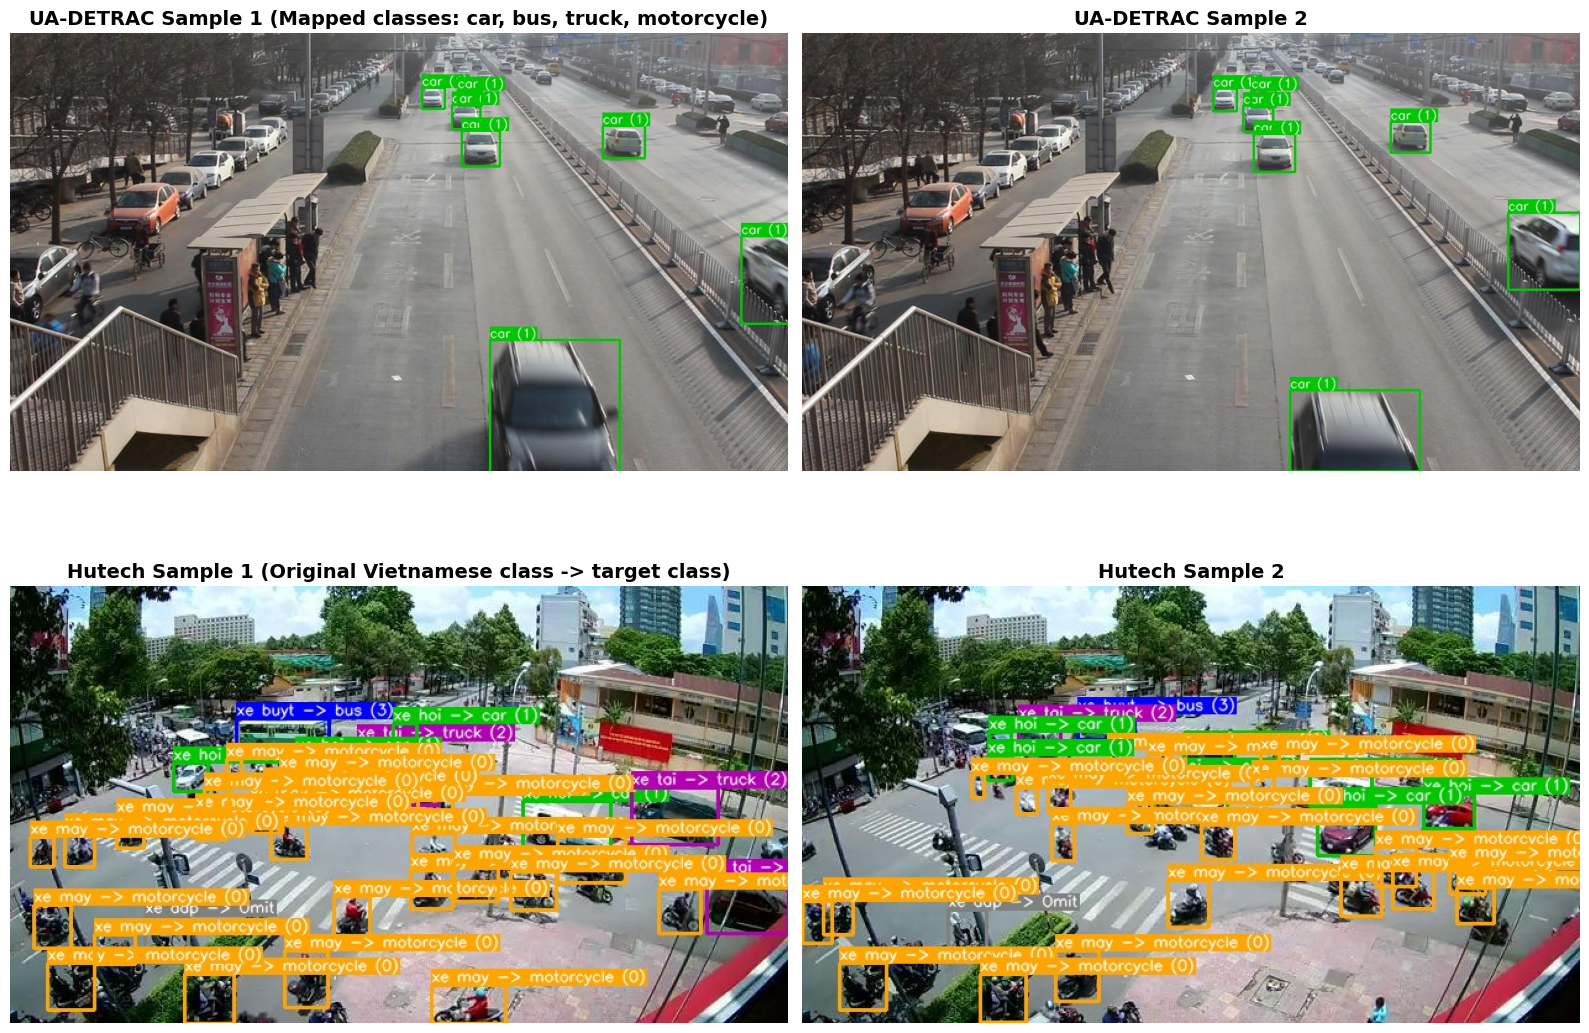

In [8]:
# Visualizing sample annotated images from both Hutech and DETRAC-YOLO
import cv2
import matplotlib.pyplot as plt
import os

output_dir = "/home/khanhduong/.gemini/antigravity/brain/817a2e9d-fe86-4ebf-86fb-a412ff2274c9/artifacts"

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Load images
detrac1 = cv2.imread(os.path.join(output_dir, "detrac_sample1.jpg"))
detrac2 = cv2.imread(os.path.join(output_dir, "detrac_sample2.jpg"))
hutech1 = cv2.imread(os.path.join(output_dir, "hutech_sample1.jpg"))
hutech2 = cv2.imread(os.path.join(output_dir, "hutech_sample2.jpg"))

# Convert BGR to RGB
detrac1 = cv2.cvtColor(detrac1, cv2.COLOR_BGR2RGB)
detrac2 = cv2.cvtColor(detrac2, cv2.COLOR_BGR2RGB)
hutech1 = cv2.cvtColor(hutech1, cv2.COLOR_BGR2RGB)
hutech2 = cv2.cvtColor(hutech2, cv2.COLOR_BGR2RGB)

# Plot
axes[0, 0].imshow(detrac1)
axes[0, 0].set_title("UA-DETRAC Sample 1 (Mapped classes: car, bus, truck, motorcycle)", fontsize=14, fontweight="bold")
axes[0, 0].axis("off")

axes[0, 1].imshow(detrac2)
axes[0, 1].set_title("UA-DETRAC Sample 2", fontsize=14, fontweight="bold")
axes[0, 1].axis("off")

axes[1, 0].imshow(hutech1)
axes[1, 0].set_title("Hutech Sample 1 (Original Vietnamese class -> target class)", fontsize=14, fontweight="bold")
axes[1, 0].axis("off")

axes[1, 1].imshow(hutech2)
axes[1, 1].set_title("Hutech Sample 2", fontsize=14, fontweight="bold")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

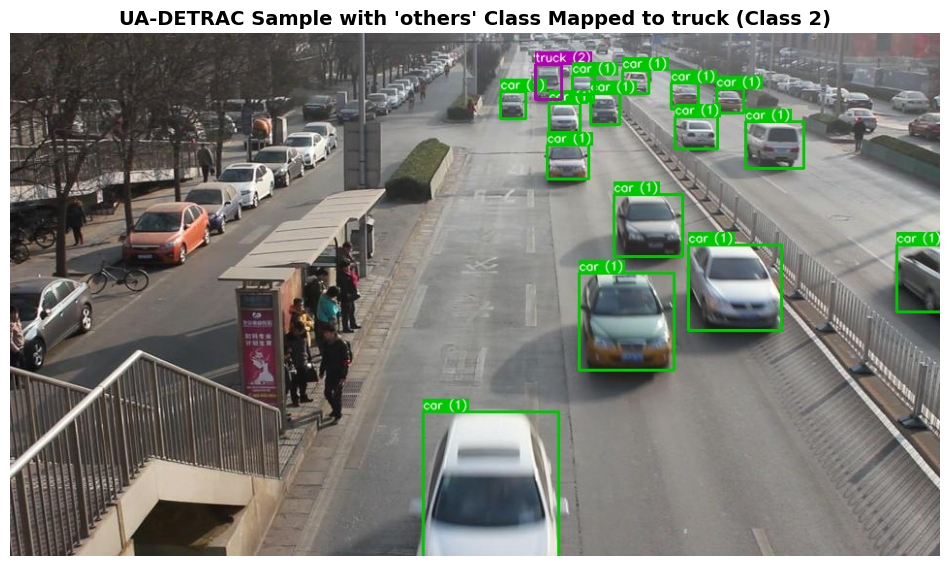

In [9]:
# Visualizing UA-DETRAC sample containing the "others" class (mapped to "truck" Class 2)
import cv2
import matplotlib.pyplot as plt
import os

output_dir = "/home/khanhduong/.gemini/antigravity/brain/817a2e9d-fe86-4ebf-86fb-a412ff2274c9/artifacts"
img_path = os.path.join(output_dir, "detrac_others_sample.jpg")

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.title("UA-DETRAC Sample with 'others' Class Mapped to truck (Class 2)", fontsize=14, fontweight="bold")
plt.axis("off")
plt.show()